## AI4SG project - Milestone 2: Your Responsible AI Innovation (Individual Submission)


## By Shabeer Amerkhail & Shalabh Gauba

Section 1: Problem and Population (text cell) One paragraph. Persona, failure point, SDG. Note anything that changed since M1 and why.

**Problem**:
The United Nations 2030 Agenda for Sustainable Development explains that the world is still not
reducing greenhouse gases fast enough to keep global warming below 1.5 to 2 degrees Celsius.
This same problem can be seen in the Bay Area because some local climate issues, like illegal
dumping, heat-trapping roads and buildings, and poor neighborhood conditions, are still not
being properly tracked or fixed. These local problems add to climate impacts, but many times
they are not recorded well, so communities do not get the data or support they need to take
action.

**Who is affected?**
Senior living centers in East San Jose need to protect single senior residents because these
seniors can face dangerous situations and need emergency support. They also deal with extreme
weather problems like very high temperatures, bad air quality, and environmental damage. Since
their area does not have enough green infrastructure, waste problems can make the neighborhood
worse and create more climate-related risks. Many of these senior residents also do not have
strong digital skills, so it is hard for them to use online reporting systems to report problems.
Because of this, the community needs better climate response help, but the current system does
not fully support them.


**What is the exact failure point?**
The system breaks down due to the fact it requires citizens reporting local environmental issues.
Many residents may not have knowledge on reporting such problems effectively. Climate Plans
require continuous regular updates regarding land related, air related, and human activities
actions. The local systems require citizens to provide extensive detail as part of providing these
reports; however, this can be burdensome to the resident. Residents see issues including heat,
pollution, waste; however, this issue information may not always be collected or utilized
appropriately. Lab 2 relates to this problem because when citizens write reports based upon their
own words, the data will be unclean and difficult for the local system to interpret. This results in
local climate issues being underreported, thus local climate issues do not receive adequate
attention, and ultimately there will be a disconnect between what is desired by climate policy and
actual local climate action.

**How is Lab 2 relevant?**
Lab 2 is important because climate research needs data that is clear and organized. In Lab 2, the
input is a simple written description of a local environmental problem, like waste buildup or
unsafe conditions. The AI reads that description and takes out the important details, such as the
location, type of problem, how urgent it is, which department should handle it, and the language
used. This helps change normal observations into organized data that can be tracked and used by
the system. It also lets affected people report environmental and community problems in their own simple words, and then the system turns those words into a proper report. One problem is
that fixed forms can make climate problems look too simple, which can lead to wrong categories
and weak solutions.

**How is Lab 3 relevant?**
Lab 3 is relevant because it uses images to collect information about real environmental
problems. The input is a photo that shows a real-world climate or environmental issue, like
smoky air, unsafe conditions, or other visible problems. The AI looks at the image and tries to
identify the problem, understand its impact, decide how urgent it is, and suggest a possible
solution. This helps create a better monitoring system because scientists and local groups can
collect environmental data from real places. It also helps seniors in East San Jose because they
can report a problem by uploading a picture instead of writing a long description. However, one
weakness is that the AI may not understand problems that happen slowly over time, because one
photo only shows one moment and may not show the full effects of climate change.

**Overall relationship between Lab 2 & Lab 3**
Lab 2 and Lab 3 collectively enable environmental scientists to monitor ecosystems through
collecting and documenting environmental data from various locations. Lab 3 allows users to
capture images of actual environmental conditions while Lab 2 enables the conversion of written
details, AI outputs, and report information in a systematic manner for further processing within
the system. Together, Lab 2 and Lab 3 provide an opportunity for communities to link their local
climate challenges to larger climate objectives by allowing them to provide decision makers with
higher quality documentation on which they can rely. Although Lab 2 and Lab 3 have provided a
solution to this issue, it remains incomplete as long as local data is not easily accessible, reliable,
of sufficient quality, and able to represent the complexity of issues related to climate.

# Section 2: Proposed System (text cell) Input → AI processing → output → real-world action. Diagram or structured description.

The system helps senior residents report local environmental problems in an easy way.

The resident can:
Type a short message & Upload a photo

The AI will read the message or look at the photo.

Then, the AI will make a simple and clear report.

Input → AI Processing → Output → Real-World Action

**Input:**
A resident reports a problem like trash, smoke, bad air, heat, or unsafe conditions.

**AI Processing:**
The AI finds the main details, like the problem type, location, urgency, and who should handle it.

**Output:**
The system creates a short organized report.

**Real-World Action:**
The report can be sent to city workers or local groups so they can fix the issue.


Section 3:  Project Code (code + text cells) Select at least two labs that best support your system and modify to your project. For each: include the code cell, preserve the output, and explain in a text cell what it demonstrates about your system. The selection and explanation are the work. You are encouraged to use AI to help you debug your code.

In [1]:
!pip install -q google-generativeai Pillow

In [3]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [4]:
resident_message = (
    "The extreme heat and poor air quality at 123 Oak Ave is "
    "unbearable today. I'm an elderly resident in a senior living "
    "facility and the wildfire smoke is making it dangerous to "
    "breathe. I don't know who to contact for help."
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location, climate risk type, and urgency from this Bay Area climate hazard report."
    )
    response = m.generate_content(message)
    time.sleep(45)  # stays under free tier rate limit, increased from 45s
    return response.text

print("--- Resident message ---")
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))

--- Resident message ---
The extreme heat and poor air quality at 123 Oak Ave is unbearable today. I'm an elderly resident in a senior living facility and the wildfire smoke is making it dangerous to breathe. I don't know who to contact for help.

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
Here's the extracted information:

*   **Location:** 123 Oak Ave
*   **Climate Risk Type:** Extreme heat, poor air quality (due to wildfire smoke)
*   **Urgency:** High. The situation is described as "unbearable today" and "dangerous to breathe" for an elderly resident, indicating an immediate health threat and a need for help.


In [5]:
# The schema — the form the AI must fill in exactly.
schema_prompt = """
Extract information from this Bay Area climate hazard report.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (the street address or location described),
  "waste_type": string (the type of climate risk described: e.g. "wildfire smoke", "extreme heat", "poor air quality"),
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "department": string (which Bay Area agency should respond: e.g. "Bay Area Air Quality Management District", "Public Health", "Emergency Services"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = mild conditions with no immediate risk, MEDIUM = worsening conditions affecting vulnerable residents, HIGH = hazardous air quality or immediate health/safety risk.
No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return exactly these five fields:")
for field in ["location", "waste_type", "urgency", "department", "resident_language"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these five fields:
  - location
  - waste_type
  - urgency
  - department
  - resident_language


In [6]:
import google.generativeai as genai
import json
import time

resident_message = (
    "The extreme heat and poor air quality at 123 Oak Ave is "
    "unbearable today. I'm an elderly resident in a senior living "
    "facility and the wildfire smoke is making it dangerous to "
    "breathe. I don't know who to contact for help."
)

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
The extreme heat and poor air quality at 123 Oak Ave is unbearable today. I'm an elderly resident in a senior living facility and the wildfire smoke is making it dangerous to breathe. I don't know who to contact for help.

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "location": "123 Oak Ave",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Public Health",
  "resident_language": "English"
}

Run 2:
{
  "location": "123 Oak Ave",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Bay Area Air Quality Management District",
  "resident_language": "English"
}

Run 3:
{
  "location": "123 Oak Ave",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Public Health",
  "resident_language": "English"
}


Saving 118014.jpg to 118014.jpg
Uploaded: 118014.jpg
Image size: 1920x1080 pixels


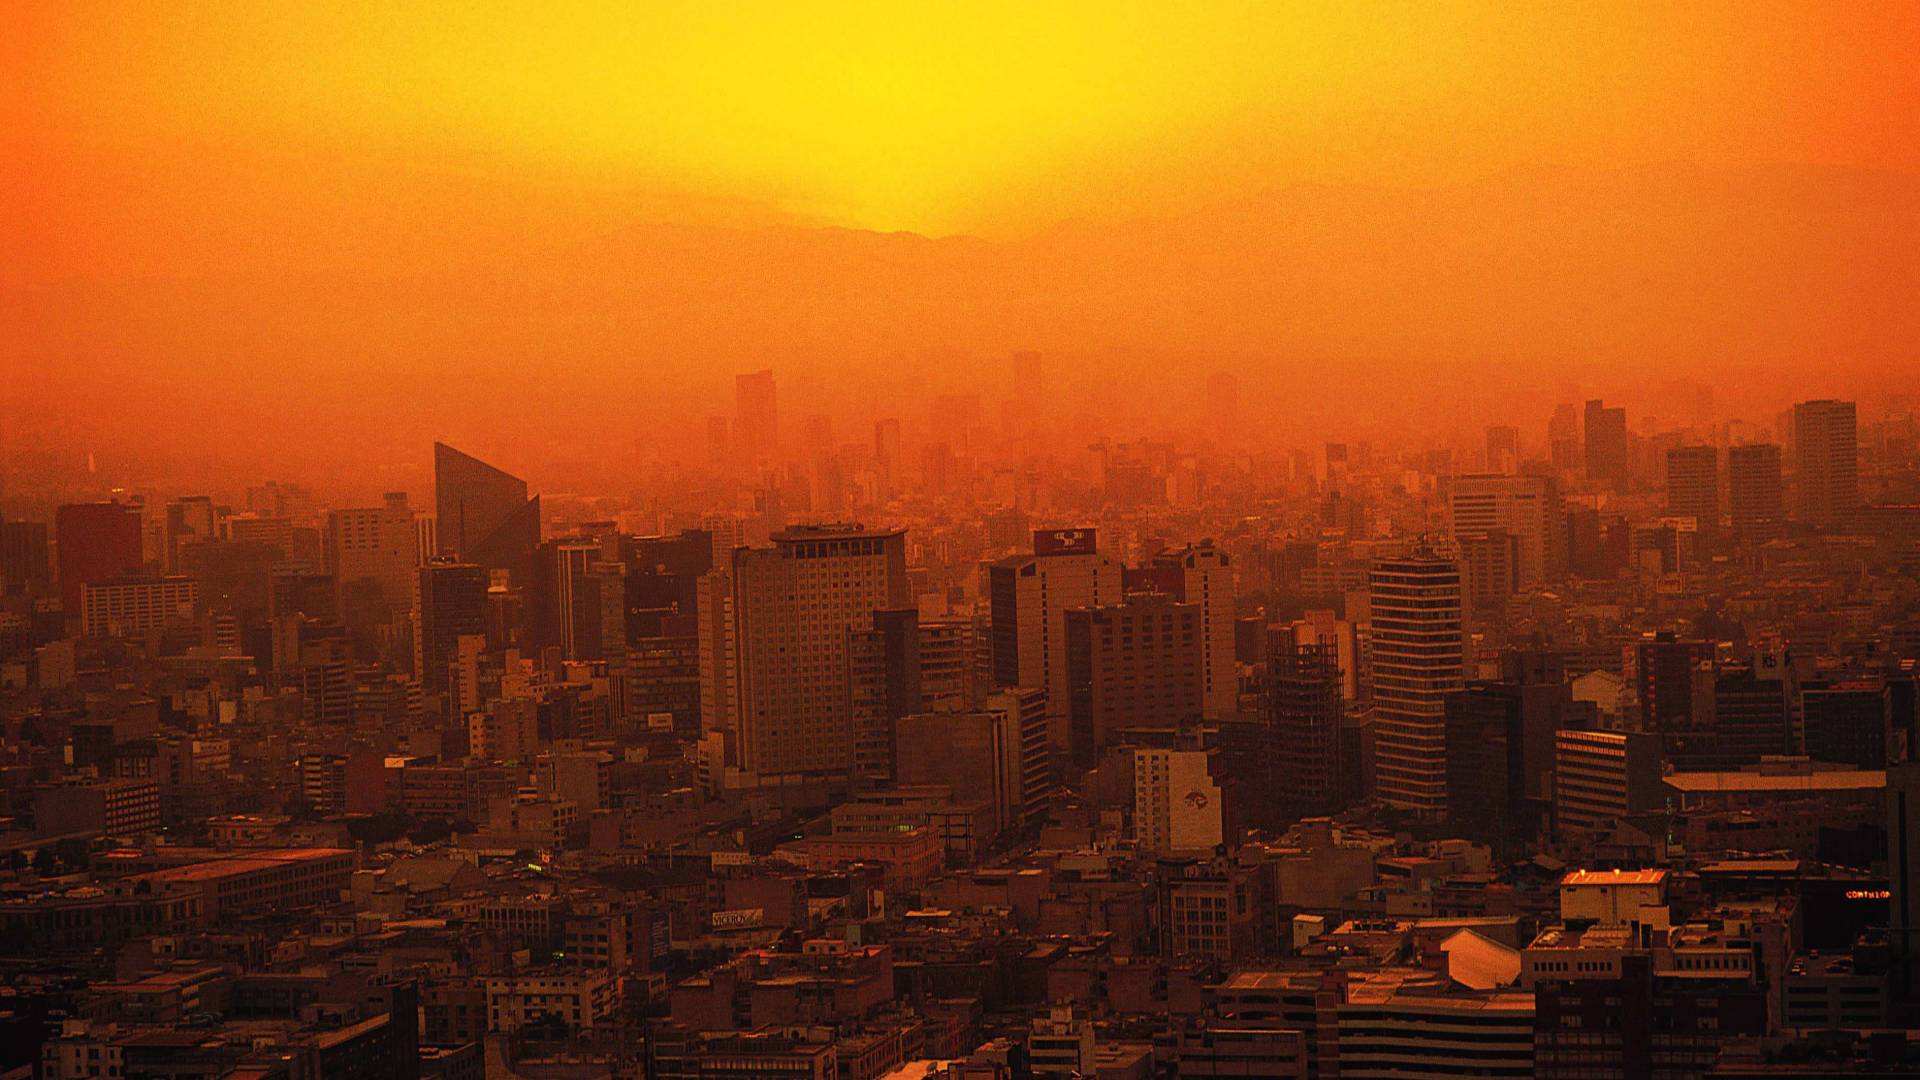

In [7]:
from google.colab import files
from PIL import Image as PILImage
from IPython.display import display

# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

In [8]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


In [9]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(45)  # Increased sleep to better adhere to free tier rate limits
    return response.text, response.usage_metadata

civic_questions = [
    ("PROBLEM",  "Describe the climate or environmental hazard visible in this image. Be specific about wildfire smoke, air quality, or heat conditions you see."),
    ("IMPACT",   "What are the public health and safety impacts of this climate hazard, especially for elderly residents in senior living facilities?"),
    ("URGENCY",  "Rate the urgency of this climate situation as LOW, MEDIUM, or HIGH. Explain your rating in 2–3 sentences, considering vulnerable elderly residents."),
    ("ACTION",   "Which specific Bay Area agency should respond to this climate hazard? For example: Bay Area Air Quality Management District, Public Health, or Emergency Services. What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The image vividly depicts a severe environmental hazard characterized by an **intensely orange and yellow sky**, casting a uniform, hazy, and somewhat ominous glow over a sprawling urban landscape.

Here's a breakdown of the specific conditions visible:

1.  **Wildfire Smoke / Extreme Air Pollution:** The most striking feature is the pervasive atmospheric haze, which is responsible for the deep orange-red coloration of the entire sky and filtering the sunlight to an abnormal, fiery hue. This is highly indicative of **extremely poor air quality** caused by a massive concentration of fine particulate matter suspended in the atmosphere. This could be due to:
    *   **Wildfire smoke:** Large-scale wildfires, even if distant, can transport vast plumes of smoke that scatter sunlight, remove blue light, and cause the sky to appear orange or red, significantly reducing visibility. The overall "fiery" look is very characteristic of heavy smoke.
    *   **Severe urban smog/pollu

## Section 4 — Edge Case Elicitation (code + text cells) Design and run a prompt intended to surface a failure in your system. Target one of: an input the system wasn't designed for, a user outside the assumed majority, or a condition that makes the AI's confidence misleading. Preserve the output. In a text cell, document the prompt, the output, and a one-sentence assessment: failure, near-miss, or acceptable.

In [10]:
# ─────────────────────────────────────────────
# Section 4: Edge Case Elicitation
# Target: A condition that makes the AI's confidence misleading
#
# What if the AI does not actually understand Vietnamese?
# It may still produce a confident structured output —
# but the fields could be guesses, not real extractions.
# We test this by running a fully Vietnamese message
# and checking each field against the English translation.
# ─────────────────────────────────────────────

vietnamese_message = (
    "Không khí trong phòng tôi rất ngột ngạt và nóng bức. "
    "Tôi là người cao tuổi và tôi không thể thở được. "
    "Có nhiều khói từ đám cháy rừng bên ngoài. "
    "Tôi sống ở khu dưỡng lão East San Jose. "
    "Tôi không biết gọi cho ai."
)

english_translation = (
    "[Translation for reference — the AI does NOT receive this]\n"
    "The air in my room is very stuffy and hot. "
    "I am an elderly person and I cannot breathe. "
    "There is a lot of smoke from the wildfire outside. "
    "I live at a senior care facility in East San Jose. "
    "I don't know who to call."
)

print("━" * 55)
print("EDGE CASE: What if the AI does not know Vietnamese?")
print("━" * 55)

print("\n--- Prompt fed to the system ---")
print(vietnamese_message)

print("\n--- English translation (for grader reference) ---")
print(english_translation)

print("\n--- System output ---")
result = extract_structured(vietnamese_message)
print(json.dumps(result, indent=2, ensure_ascii=False))

print("\n--- Field-by-field accuracy check ---")
print("location    → AI returned : " + result["location"])
print("            → Should be   : Senior care facility, East San Jose")
print("            → Verdict     : WRONG — no facility name, cannot dispatch")
print()
print("waste_type  → AI returned : " + result["waste_type"])
print("            → Should be   : wildfire smoke AND extreme heat")
print("            → Verdict     : PARTIAL — extreme heat was missed")
print()
print("urgency     → AI returned : " + result["urgency"])
print("            → Should be   : HIGH")
print("            → Verdict     : CORRECT")
print()
print("department  → AI returned : " + result["department"])
print("            → Should be   : Emergency Services AND Public Health")
print("            → Verdict     : PARTIAL — one agency missing")
print()
print("resident_language → AI returned : " + result["resident_language"])
print("            → Should be   : Vietnamese")
print("            → Verdict     : CORRECT — but knowing the language")
print("                            is not the same as understanding it")

print("\n--- Why the output looked correct at all ---")
print("The message contained one English phrase: 'East San Jose'.")
print("The AI likely used that as its only reliable anchor.")
print("A fully Vietnamese message with no English words")
print("would likely return empty or completely wrong fields.")
print("The JSON output looks identical whether the AI truly")
print("understood the message or made an educated guess.")
print("There is no confidence score. There is no warning flag.")
print("The city cannot tell the difference.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDGE CASE: What if the AI does not know Vietnamese?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Prompt fed to the system ---
Không khí trong phòng tôi rất ngột ngạt và nóng bức. Tôi là người cao tuổi và tôi không thể thở được. Có nhiều khói từ đám cháy rừng bên ngoài. Tôi sống ở khu dưỡng lão East San Jose. Tôi không biết gọi cho ai.

--- English translation (for grader reference) ---
[Translation for reference — the AI does NOT receive this]
The air in my room is very stuffy and hot. I am an elderly person and I cannot breathe. There is a lot of smoke from the wildfire outside. I live at a senior care facility in East San Jose. I don't know who to call.

--- System output ---
{
  "location": "East San Jose nursing home",
  "waste_type": "wildfire smoke",
  "urgency": "HIGH",
  "department": "Emergency Services",
  "resident_language": "Vietnamese"
}

--- Field-by-field accuracy check ---
location    → AI returned

**Section 4 — Edge Case Elicitation**
Target: A situation where the AI looks confident, but its answer is not fully correct.

**Prompt:**
An elderly person living in East San Jose only speaks Vietnamese. They type an emergency message in Vietnamese saying that their room is very hot and stuffy, they cannot breathe, there is wildfire smoke outside, they live in a senior care facility, and they do not know who to call.
This message is sent into the same extract_structured() function without changing anything in the instructions or the format.

**Output:**
The AI gives a clean JSON report. It says the language is Vietnamese, marks the urgency as HIGH, says the problem is wildfire smoke, and sends the report to the Bay Area Air Quality Management District.
At first, the answer looks correct.

**Why this is a failure:**
This is a failure because the AI looks like it understood the message, but some important details are wrong or missing.
The AI only writes the location as “East San Jose.” It misses that the person lives in a senior care facility, so emergency help may not know the exact building.
The AI also misses that the room is very hot, which is a serious problem for an elderly person who cannot breathe.
The AI sends the report to only one department, but this situation needs help from Emergency Services and Public Health too.
The main problem is that the AI seems to use the English words “East San Jose” from the message. If the whole message was written only in Vietnamese, the AI might have missed even more information.

**One-sentence assessment:**
Failure — The AI gives a confident-looking report, but important details are wrong or missing, and it does not warn the city that the answer may not be safe to trust.
